In [1]:
# Imports
# pip install kagglehub[pandas-datasets]
#import kagglehub
#from kagglehub import KaggleDatasetAdapter
import os
import random
from glob import glob
import cv2 
import matplotlib.pylab as plt
import seaborn as sns
import pandas as pd
import numpy as np


import snntorch as snn
from snntorch import spikeplot as splt
from snntorch import spikegen

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
from sklearn.metrics import classification_report

import argparse
#import torch
#import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
#from torchvision import datasets, transforms
from torch.optim.lr_scheduler import StepLR
from collections import Counter

# from codecarbon import EmissionsTracker
from carbontracker.tracker import CarbonTracker

c:\Users\giueg\.virtualenvs\TCC_25-OGy0qkdu\Lib\site-packages\torch\cuda\__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


# DATA

In [2]:
class CustomImageDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx].astype(np.uint8)
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

# Load the data(images)
x_npz = np.load("../../data/x_images_arrays_2_class.npz")
X = x_npz["arr_0"]
y_npz = np.load("../../data/y_labels_arrays_2_class.npz")
Y = y_npz["arr_0"]

print("x = ", np.array(X).shape)
print("Y = ", np.array(Y).shape)

# Separete the data into train and test sets
# 80% train, 20% test
x_train_old, x_test, y_train_old, y_test = train_test_split(X, Y, test_size=0.2,random_state=1, stratify=Y)

x_train_aux = np.load("../../data/x_images_arrays_under_train_2_class.npz")
x_train = x_train_aux["arr_0"]
y_train_aux = np.load("../../data/y_labels_arrays_under_train_2_class.npz")
y_train = y_train_aux["arr_0"]

#x_test, x_val, y_test, y_val = train_test_split(x_temp, y_temp, test_size=0.5, random_state=1, stratify=y_temp)

print("\nForma dos dados de treino:", np.array(x_train).shape) # (3045, 128, 128, 3)
print("Distribuição train antes:", Counter(y_train)) #np.int64(0): 2435, np.int64(2): 402, np.int64(1): 208
#print(np.array(x_val).shape)
print("Forma dos dados de teste:", np.array(x_test).shape) # (762, 128, 128, 3)
print("Distribuição test antes:", Counter(y_test)) #np.int64(0): 609, np.int64(2): 101, np.int64(1): 52

# Transform the data to tensor
# Define a transform
transform = transforms.Compose([
            #transforms.Resize((28, 28)),
            transforms.ToPILImage(),
            transforms.Grayscale(),
            transforms.ToTensor(),
            transforms.Normalize((0,), (1,))])

# Apply the transform to the data
dataset_train = CustomImageDataset(x_train, y_train, transform=transform)
#dataset_val = CustomImageDataset(x_val, y_val, transform=transform)
dataset_test = CustomImageDataset(x_test, y_test, transform=transform)

img, label = dataset_train[0]
print("\nForma do img e label:", img.shape, label) # [grayscale=1, size=128, size=128] label=0 ('Nothing')
print("Quantidade dados de treino:", dataset_train.__len__()) # 610 images
#print(dataset_val.__len__()) # 0 images
print("Quantidade dados de teste:", dataset_test.__len__()) # 762 images

# Load into the DataLoader
batch_size = 32

train_loader = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
#val_loader = DataLoader(dataset_val, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset_test, batch_size=batch_size, shuffle=True)


x =  (3547, 128, 128, 3)
Y =  (3547,)

Forma dos dados de treino: (804, 128, 128, 3)
Distribuição train antes: Counter({np.int64(0): 402, np.int64(1): 402})
Forma dos dados de teste: (710, 128, 128, 3)
Distribuição test antes: Counter({np.int64(0): 609, np.int64(1): 101})

Forma do img e label: torch.Size([1, 128, 128]) 0
Quantidade dados de treino: 804
Quantidade dados de teste: 710


# NETWORK

### Define

In [3]:
# Network Architecture
entry_channels = 1
mid_channels = 6
exit_channels = 16
kernel_size = 5
padding = 2
num_inputs = 128*128
num_hidden = 1000
num_outputs = 2 # classes
num_steps = 20
beta = 0.95

# Use GPU if available
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
dtype = torch.float
class SpkLeNet(nn.Module):
    def __init__(self):
        super(SpkLeNet, self).__init__()
        # Camada convolucional 1: 1 canal -> 6 canais, kernel 5x5, padding 2
        self.conv1 = nn.Conv2d(entry_channels, mid_channels, kernel_size, padding=padding, stride=1)
        # Max pooling 2x2
        self.lif1 = snn.Leaky(beta=beta)
        self.pool = nn.MaxPool2d(2, 2)
        # Camada convolucional 2: 6 canais -> 16 canais, kernel 5x5
        self.conv2 = nn.Conv2d(mid_channels, exit_channels, kernel_size)
        self.lif2 = snn.Leaky(beta=beta)
        # Camadas fully connected 
        self.fc1 = nn.Linear(exit_channels * 30 * 30, 120)  # 30x30 após conv2+pool2
        self.lif3 = snn.Leaky(beta=beta)
        self.fc2 = nn.Linear(120, 84)
        self.lif4 = snn.Leaky(beta=beta)
        self.fc3 = nn.Linear(84, num_outputs)
        self.lif5 = snn.Leaky(beta=beta)

    def forward(self, x):

        # Initialize hidden states at t=0
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()
        mem4 = self.lif4.init_leaky()
        mem5 = self.lif5.init_leaky()
 
        # Record the final layer
        spk5_rec = []
        mem5_rec = []

        for step in range(num_steps):
            cur1 = self.conv1(x[step, :, :, :, :])
            spk1, mem1 = self.lif1(cur1, mem1)
            pool1 = self.pool(spk1)
            cur2 = self.conv2(pool1)
            spk2, mem2 = self.lif2(cur2, mem2)
            pool2 = self.pool(spk2)
            flat = torch.flatten(pool2, 1)

            cur3 = self.fc1(flat)
            spk3, mem3 = self.lif3(cur3, mem3)
            cur4 = self.fc2(spk3)
            spk4, mem4 = self.lif4(cur4, mem4)
            cur5 = self.fc3(spk4)
            spk5, mem5 = self.lif5(cur5, mem5) # testar com saida direto da fc3

            spk5_rec.append(spk5)
            mem5_rec.append(mem5)

        return torch.stack(spk5_rec, dim=0), torch.stack(mem5_rec, dim=0)

# Instanciar o modelo
net = SpkLeNet().to(device)

def to_spike(data, num_steps):
    return spikegen.latency(data, num_steps=num_steps, tau=1, 
                            threshold=0.001, clip=True, normalize=True, linear=True)

In [4]:
# Metrics
# Accuracy
# pass data into the network, sum the spikes over time
# and compare the neuron with the highest number of spikes
# with the target

def print_batch_accuracy(data, targets, train=False):
    output = net(data)
    _, idx = output.max(1)
    acc = np.mean((targets == idx).detach().cpu().numpy())

    if train:
        print(f"Train set accuracy for a single minibatch: {acc*100:.2f}%")
    else:
        print(f"Test set accuracy for a single minibatch: {acc*100:.2f}%")

def train_printer():
    print(f"Epoch {epoch}, Iteration {iter_counter}")
    print(f"Train Set Loss: {loss_hist[counter]:.2f}")
    print(f"Test Set Loss: {test_loss_hist[counter]:.2f}")
    print_batch_accuracy(data, targets, train=True)
    print_batch_accuracy(test_data, test_targets, train=False)
    print("\n")

# Função para calcular métricas
def calculate_metrics(y_true, y_pred):
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro') # average = 'weighted' | 'micro' | 'macro'
    return precision, recall, f1

# loss
# 1. Contar quantos exemplos de cada classe existem no dataset
# targets_list = []

# # Percorre todo o conjunto de treino para pegar os rótulos
# for _, targets in train_loader:
#     targets_list.extend(targets.tolist())

# class_counts = Counter(targets_list)
# total_samples = sum(class_counts.values())

# # 2. Calcular o peso inverso à frequência (quanto menos amostras, maior o peso)
# num_classes = len(class_counts)
# class_weights = []

# for i in range(num_classes):
#     count = class_counts[i]
#     weight = total_samples / (num_classes * count)
#     class_weights.append(weight)

# # 3. Criar tensor e mover para o mesmo dispositivo da rede
# class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

# 4. Redefinir a função de perda com pesos
# loss = nn.CrossEntropyLoss(weight=class_weights)

# Total samples
# total = 402 + 208 + 402

# # Frequência relativa inversa
# w0 = total / (3 * 402)
# w1 = total / (3 * 208)
# w2 = total / (3 * 402)

# # Tensor com pesos
# weights = torch.tensor([w0, w1, w2], dtype=torch.float).to(device)

# # Loss ponderado
# loss = nn.CrossEntropyLoss(weight=weights)

# class FocalLoss(nn.Module):
#     def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
#         super(FocalLoss, self).__init__()
#         self.alpha = alpha
#         self.gamma = gamma
#         self.reduction = reduction

#     def forward(self, inputs, targets):
#         ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
#         pt = torch.exp(-ce_loss)
#         focal_loss = ((1 - pt) ** self.gamma) * ce_loss

#         if self.reduction == 'mean':
#             return focal_loss.mean()
#         elif self.reduction == 'sum':
#             return focal_loss.sum()
#         else:
#             return focal_loss


# Class-Balanced Loss
beta = 0.95
class_counts = [402, 101]
effective_num = [(1 - beta) / (1 - beta ** count) for count in class_counts]
weights = torch.tensor(effective_num, dtype=torch.float).to(device)
loss = nn.CrossEntropyLoss(weight=weights)

# loss = FocalLoss(alpha=weights, gamma=2.0)
# loss = nn.CrossEntropyLoss()  # Sem pesos, pois o dataset já está balanceado

# optimizer
optimizer = torch.optim.Adam(net.parameters(), lr=5e-4)

### Training Loop

In [5]:
PATH = '../../models/snn_conv_30_2_class_under_class_weights_carbontraker_20_num_steps_120725.pth'

In [24]:
# Training loop
num_epochs = 30
loss_hist = []
test_loss_hist = []

history = {
    "loss_hist": [],
    "test_loss_hist": [],
    "precision": [],
    "recall": [],
    "f1": []
}

counter = 0

# Early stopping parameters
best_f1 = 0
epochs_no_improve = 0
early_stop_patience = 20  # quantas épocas esperar sem melhoria

# tracker = EmissionsTracker()
# tracker.start()

# Configurar o CarbonTracker
tracker = CarbonTracker(
    epochs=num_epochs,  # Total de épocas (definido no seu código original)
    epochs_before_pred=1,  # Medir energia na primeira época e prever para as demais
    monitor_epochs=-1,  # -1 significa monitorar todas as épocas
    update_interval=1,  # Intervalo de atualização em segundos
    log_dir="./carbon_logs"  # Diretório para salvar logs
    # log_level=1  # Nível de verbosidade (1 = info, 2 = debug)
)

# Outer training loop
for epoch in range(num_epochs):
    tracker.epoch_start()

    iter_counter = 0
    train_batch = iter(train_loader)
    running_train_loss = 0.0
    
    # Minibatch training loop
    for data, targets in train_batch:
        #print(epoch, iter_counter, counter)
        data = data.to(device)
        targets = targets.to(device)

        # forward pass
        net.train()
        spike_data = to_spike(data, num_steps)
        # spike_data = spikegen.latency(data, num_steps=num_steps, tau=1, threshold=0.001, clip=True, normalize=True, linear=True)
        #print(f"Spike data size (latency 2): {spike_data.size()}")

        spk_rec, mem_rec = net(spike_data)

        # initialize the loss & sum over time
        # loss_val = torch.zeros((1), dtype=dtype, device=device)
        # for step in range(num_steps):
        #     loss_val += loss(mem_rec[step], targets)
        loss_val = loss(mem_rec.mean(dim=0), targets)

        # Gradient calculation + weight update
        optimizer.zero_grad()
        loss_val.backward()
        optimizer.step()

        # Store loss history for future plotting
        loss_hist.append(loss_val.item())
        running_train_loss += loss_val.item()

        running_test_loss = 0.0
        # Test set
        with torch.no_grad():
            net.eval()
            test_data, test_targets = next(iter(test_loader))
            test_data = test_data.to(device)
            test_targets = test_targets.to(device)

            test_spike_data = to_spike(test_data, num_steps)
            # test_spike_data = spikegen.latency(test_data, num_steps=num_steps, tau=1, threshold=0.001, clip=True, normalize=True, linear=True)

            # Test set forward pass
            test_spk, test_mem = net(test_spike_data)

            # Test set loss
            # test_loss = torch.zeros((1), dtype=dtype, device=device)
            # for step in range(num_steps):
            #     test_loss += loss(test_mem[step], test_targets)
            test_loss = loss(test_mem.sum(dim=0), test_targets)
            test_loss_hist.append(test_loss.item())
            running_test_loss += test_loss.item()

            # Print train/test loss/accuracy
            #if counter % 32 == 0:
                #train_printer()
            counter += 1
            iter_counter += 1
    
    # Early stopping check
    net.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for test_data_2, test_targets_2 in test_loader:
            test_data_2 = test_data_2.to(device)
            test_targets_2 = test_targets_2.to(device)

            test_spike_data_2 = spikegen.latency(test_data_2, num_steps=num_steps, tau=1, threshold=0.001, clip=True, normalize=True, linear=True)

            output_2, _ = net(test_spike_data_2)
            _, predicted_2 = output_2.mean(dim=0).max(1)

            all_preds.extend(predicted_2.cpu().numpy())
            all_targets.extend(test_targets_2.cpu().numpy())

    # Calcular F1-score para early stopping
    precision, recall, f1 = calculate_metrics(all_targets, all_preds)

    # precisions.append(precision)
    # recalls.append(recall)
    # f1s.append(f1)
    history["precision"].append(precision)
    history["recall"].append(recall)
    history["f1"].append(f1)

    # Média do loss de treinamento da época
    epoch_train_loss = running_train_loss / len(train_loader)
    history["loss_hist"].append(epoch_train_loss)
    
    epoch_test_loss = running_test_loss / len(test_loader)
    history["test_loss_hist"].append(epoch_test_loss)

    print(f"\n[Epoch {epoch+1}] F1-score: {f1:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f}")

    # Early Stopping com base no F1-score
    if f1 > best_f1:
        best_f1 = f1
        epochs_no_improve = 0
        torch.save(net.state_dict(), PATH)
        print("🟢 Novo melhor modelo salvo!")
    else:
        epochs_no_improve += 1
        print(f"🔸 Sem melhoria. Épocas sem progresso: {epochs_no_improve}/{early_stop_patience}")

    tracker.epoch_end()

    if epochs_no_improve >= early_stop_patience:
        print(f"\n⛔ Early stopping ativado após {epoch+1} épocas. Melhor F1-score: {best_f1:.4f}")
        break

emissions = tracker.stop()  # Finalizar e obter emissões totais
print(f"Emissões totais estimadas: {emissions} kgCO2eq")

# emissions = tracker.stop()
# print(f"Emissões estimadas: {emissions} kgCO2eq")

CarbonTracker: INFO - Detected CPU: AMD Ryzen 5 5500U with Radeon Graphics
CarbonTracker: WARNING - No matching TDP found for CPU: AMD Ryzen 5 5500U with Radeon Graphics. Using average TDP of 35.61W at 50% utilization as fallback.
CarbonTracker: The following components were found: CPU with device(s) AMD Ryzen 5 5500U with Radeon Graphics.
CarbonTracker: WARNING - ElectricityMaps API key not set. Will default to average carbon intensity.
CarbonTracker: WARNING - Failed to retrieve carbon intensity: Defaulting to average carbon intensity 98.34824 gCO2/kWh.

[Epoch 1] F1-score: 0.1245 | Precision: 0.0711 | Recall: 0.5000
🟢 Novo melhor modelo salvo!
CarbonTracker: WARNING - ElectricityMaps API key not set. Will default to average carbon intensity.


c:\Users\giueg\.virtualenvs\TCC_25-OGy0qkdu\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


CarbonTracker: WARNING - Failed to retrieve carbon intensity: Defaulting to average carbon intensity 98.34824 gCO2/kWh.
CarbonTracker: Live carbon intensity could not be fetched at detected location: Bauru, São Paulo, BR. Defaulted to average carbon intensity for BR in 2023 of 98.35 gCO2/kWh. at detected location: Bauru, São Paulo, BR.
CarbonTracker: 
Predicted consumption for 30 epoch(s):
	Time:	1:14:20
	Energy:	0.069701257249 kWh
	CO2eq:	6.854995976190 g
	This is equivalent to:
	0.063767404430 km travelled by car


c:\Users\giueg\.virtualenvs\TCC_25-OGy0qkdu\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



[Epoch 2] F1-score: 0.4617 | Precision: 0.4289 | Recall: 0.5000
🟢 Novo melhor modelo salvo!


c:\Users\giueg\.virtualenvs\TCC_25-OGy0qkdu\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



[Epoch 3] F1-score: 0.4617 | Precision: 0.4289 | Recall: 0.5000
🔸 Sem melhoria. Épocas sem progresso: 1/20
CarbonTracker: WARNING - ElectricityMaps API key not set. Will default to average carbon intensity.
CarbonTracker: WARNING - Failed to retrieve carbon intensity: Defaulting to average carbon intensity 98.34824 gCO2/kWh.

[Epoch 4] F1-score: 0.5658 | Precision: 0.5712 | Recall: 0.5621
🟢 Novo melhor modelo salvo!

[Epoch 5] F1-score: 0.5123 | Precision: 0.5714 | Recall: 0.5199
🔸 Sem melhoria. Épocas sem progresso: 1/20

[Epoch 6] F1-score: 0.5012 | Precision: 0.5375 | Recall: 0.5116
🔸 Sem melhoria. Épocas sem progresso: 2/20
CarbonTracker: WARNING - ElectricityMaps API key not set. Will default to average carbon intensity.
CarbonTracker: WARNING - Failed to retrieve carbon intensity: Defaulting to average carbon intensity 98.34824 gCO2/kWh.

[Epoch 7] F1-score: 0.4008 | Precision: 0.5711 | Recall: 0.6221
🔸 Sem melhoria. Épocas sem progresso: 3/20

[Epoch 8] F1-score: 0.4143 | Preci

In [ ]:
# Código extra para salvar o modelo
# PATH = '../../models/snn_full_4_under_class_weights_over_v2.pth'
# torch.save(net.state_dict(), PATH)
# print(f"Modelo salvo com sucesso em: {PATH}")

Modelo salvo com sucesso em: ../../models/ann_full_4_under.pth


In [6]:
# Carregar melhor modelo após o treinamento
net.load_state_dict(torch.load(PATH))
net.eval()

SpkLeNet(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (lif1): Leaky()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (lif2): Leaky()
  (fc1): Linear(in_features=14400, out_features=120, bias=True)
  (lif3): Leaky()
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (lif4): Leaky()
  (fc3): Linear(in_features=84, out_features=2, bias=True)
  (lif5): Leaky()
)

### Metrics

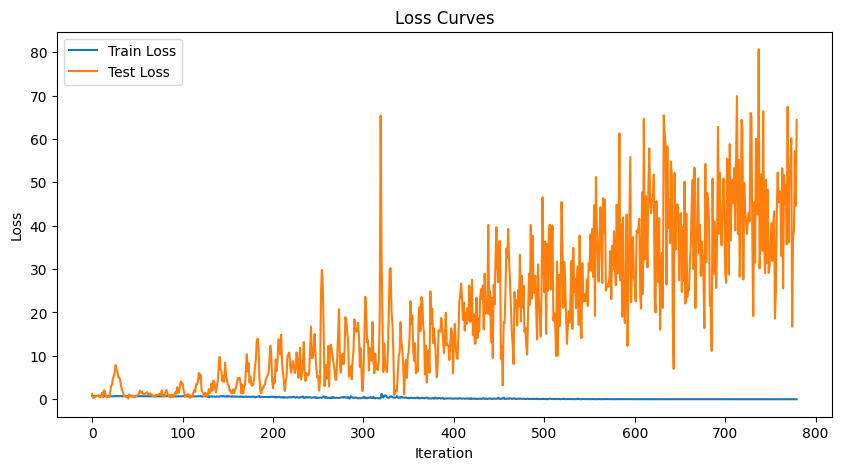

In [26]:
# For iteration
# Plot Loss
fig = plt.figure(facecolor="w", figsize=(10, 5))
plt.plot(loss_hist)
plt.plot(test_loss_hist)
plt.title("Loss Curves")
plt.legend(["Train Loss", "Test Loss"])
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()


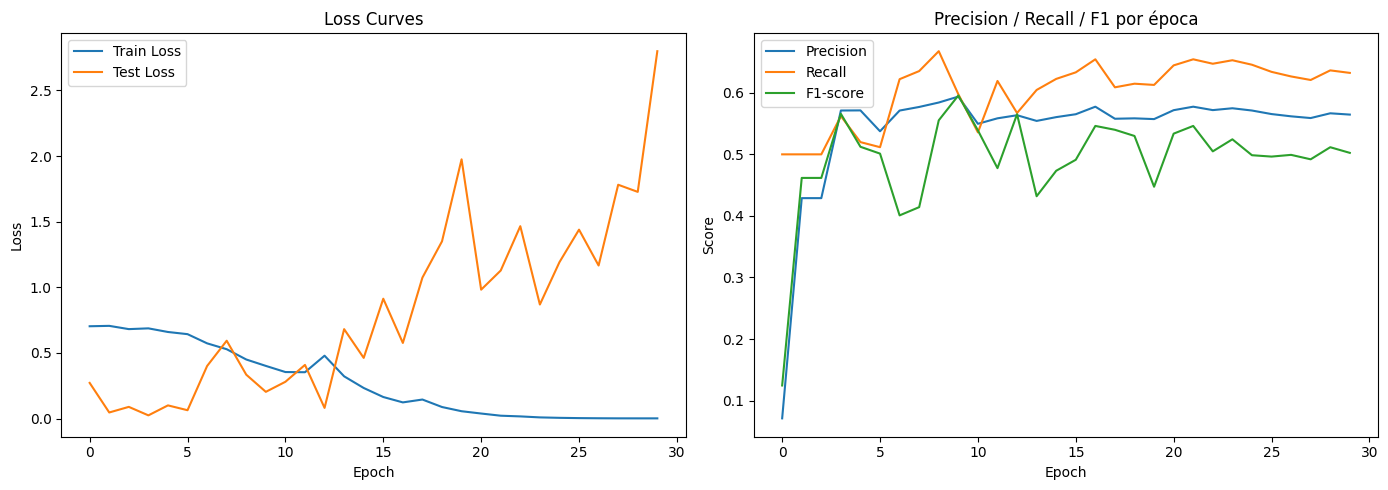

In [27]:
# For epoch
# Cria figura com 2 subplots lado a lado
fig, axs = plt.subplots(1, 2, figsize=(14, 5), facecolor="w")

# --- Loss ---
axs[0].plot(history["loss_hist"], label="Train Loss")
axs[0].plot(history["test_loss_hist"], label="Test Loss")
axs[0].set_title("Loss Curves")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Loss")
axs[0].legend()

# --- Métricas ---
axs[1].plot(history["precision"], label="Precision")
axs[1].plot(history["recall"], label="Recall")
axs[1].plot(history["f1"], label="F1-score")
axs[1].set_title("Precision / Recall / F1 por época")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Score")
axs[1].legend()

plt.tight_layout()
plt.show()


In [7]:
# Análise detalhada no conjunto de teste
import torch
import torch.nn as nn
from collections import defaultdict
import numpy as np

def register_activation_hooks(model, layer_types=(nn.Linear, nn.Conv2d)):
    activations = defaultdict(list)  # activations[layer_name] -> list of tensors per batch

    hooks = []

    def make_hook(name):
        def hook(module, input, output):
            # output shape: (batch, features, ...) -> vamos achatar por unidade de neurônio
            out = output.detach().cpu()
            # se conv2d, colapsa HxW para contar neurônios por mapa de feature
            if out.dim() > 2:
                # out shape -> (B, C, H, W) -> tomamos media espacial por neurônio (ou somar se preferir)
                # Para contar neurônios ativos, tratamos cada canal como "neurônio" e usa-se max/mean
                # Aqui optamos por max sobre HxW para considerar se alguma posição ativa => neurônio ativo
                out_per_neuron = out.view(out.size(0), out.size(1), -1).max(dim=2).values
            else:
                out_per_neuron = out  # (B, features)
            activations[name].append(out_per_neuron)  # list de (B, features)
        return hook

    for name, module in model.named_modules():
        if isinstance(module, layer_types):
            h = module.register_forward_hook(make_hook(name))
            hooks.append(h)

    def remove_hooks():
        for h in hooks:
            h.remove()

    return activations, remove_hooks

def compute_active_stats_from_activations(activations):
    """
    activations: dict layer_name -> list of tensors (each tensor shape (B, features))
    retorna estatísticas:
      - active_count_layer: dict layer_name -> np.array shape (N_samples,)
      - active_mean_layer: dict layer_name -> float
      - mean_global_active: float
    """
    active_count_layer = {}
    active_mean_pos_layer = {}
    active_mean_layer = {}
    sparsity_layer = {}
    # primeiro concatenar todas batches por layer
    for layer, list_tensors in activations.items():
        if len(list_tensors) == 0:
            continue
        all_t = torch.cat(list_tensors, dim=0)  # (N_total, features)
        # contagem de neurônios ativos por amostra (valor > 0)
        active_mask = (all_t > 0)
        active_counts = active_mask.sum(dim=1).numpy()  # (N_samples,)
        active_count_layer[layer] = active_counts

        # média de neurônios ativos por amostra
        active_mean_layer[layer] = float(active_counts.mean())

        # média das ativações apenas onde > 0 (intensidade)
        pos_values = all_t[all_t > 0]
        active_mean_pos_layer[layer] = float(pos_values.mean().item()) if pos_values.numel() > 0 else 0.0

        # sparsity
        total_neurons = all_t.size(1)
        sparsity_layer[layer] = 1.0 - (active_counts.mean() / total_neurons)

    # global per sample
    # assumir que todas layers tem N_samples iguais e ordenadas
    layers = list(active_count_layer.keys())
    counts_matrix = np.stack([active_count_layer[L] for L in layers], axis=0)  # (n_layers, N_samples)
    global_active_per_sample = counts_matrix.sum(axis=0)
    mean_global_active = float(global_active_per_sample.mean())

    return {
        "active_count_layer": active_count_layer,
        "active_mean_layer": active_mean_layer,
        "active_mean_pos_layer": active_mean_pos_layer,
        "sparsity_layer": sparsity_layer,
        "global_active_per_sample": global_active_per_sample,
        "mean_global_active": mean_global_active,
        "layers": layers
    }


In [ ]:
# Inferência
# Medir por neurônios ativos
activations, remove_hooks = register_activation_hooks(net)

# Função para calcular métricas
def calculate_metrics(y_true, y_pred):
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro') # average = 'weighted' | 'micro' | 'macro'
    return precision, recall, f1

# Criar um novo tracker só para inferência
inference_tracker = CarbonTracker(
    epochs=1,               # só uma "época" (inferência completa)
    epochs_before_pred=1,   # medir direto
    monitor_epochs=-1,      # medir todas
    update_interval=1,
    log_dir="./carbon_logs_inference"
)

inference_tracker.epoch_start()  # início da medição


# Listas para armazenar previsões e rótulos verdadeiros
all_preds_2 = []
all_targets_2 = []

# Avaliação do modelo
total = 0
correct = 0

with torch.no_grad():
    net.eval()
    for data_3, targets_3 in test_loader:
        data_3 = data_3.to(device)
        targets_3 = targets_3.to(device)

        # Converter dados para spikes
        spike_data_3 = spikegen.latency(data_3, num_steps=num_steps, tau=1, threshold=0.001, clip=True, normalize=True, linear=True)

        # Forward pass
        test_spk, _ = net(spike_data_3)

        # Previsões
        _, predicted = test_spk.sum(dim=0).max(1)

        # Acumular acurácia
        total += targets_3.size(0)
        correct += (predicted == targets_3).sum().item()

        # Armazenar previsões e rótulos para F1 e matriz de confusão
        all_preds_2.extend(predicted.cpu().numpy())
        all_targets_2.extend(targets_3.cpu().numpy())

inference_tracker.epoch_end()   # fim da medição  

stats = compute_active_stats_from_activations(activations)
remove_hooks()

print(f"\n--- Resultados Detalhados no Conjunto de Teste ---")

# Calcular acurácia
print(f"Total correctly classified test set images: {correct}/{total}")
print(f"Test Set Accuracy: {100 * correct / total:.2f}%")

# Calcular precisão, recall e F1-score
precision, recall, f1 = calculate_metrics(all_targets_2, all_preds_2) 
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-score: {f1:.2f}")

# Calcular e exibir a matriz de confusão
conf_matrix = confusion_matrix(all_targets_2, all_preds_2)
print("\nMatriz de Confusão:")
print(conf_matrix)

# Relatório detalhado por classe
print("\nClassification Report:")
print(classification_report(all_targets_2, all_preds_2, digits=4))

# Estatísticas de atividade dos neurônios
print("\n--- Métricas de Atividade dos Neurônios Ativos ---")
for layer in stats["layers"]:
    print(f"{layer}: média de neurônios ativos = {stats['active_mean_layer'][layer]:.2f}, "
          f"sparsity = {stats['sparsity_layer'][layer]*100:.1f}%")

print(f"\nMédia global de neurônios ativos por amostra: {stats['mean_global_active']:.2f}")

# Calcular sparsity global como média das sparsities por camada
global_sparsity = np.mean(list(stats['sparsity_layer'].values()))
print(f"Sparsity global: {global_sparsity*100:.1f}%")

# Estimativa simples de energia
# Assumindo custo de 1e-9 J/op
energy_per_op = 1e-9
print("\n--- Estimativa de Energia (simplificada) ---")
for layer in stats["layers"]:
    mean_active = stats['active_mean_layer'][layer]
    try:
        ops_per_activation = net._modules[layer].in_features  # se for Linear
    except:
        ops_per_activation = 1  # fallback
    E_layer = mean_active * ops_per_activation * energy_per_op
    print(f"{layer}: {E_layer:.2e} J")

CarbonTracker: INFO - Detected CPU: AMD Ryzen 5 5500U with Radeon Graphics
CarbonTracker: WARNING - No matching TDP found for CPU: AMD Ryzen 5 5500U with Radeon Graphics. Using average TDP of 35.61W at 50% utilization as fallback.
CarbonTracker: The following components were found: CPU with device(s) AMD Ryzen 5 5500U with Radeon Graphics.
CarbonTracker: WARNING - ElectricityMaps API key not set. Will default to average carbon intensity.
CarbonTracker: WARNING - Failed to retrieve carbon intensity: Defaulting to average carbon intensity 98.34824 gCO2/kWh.
CarbonTracker: WARNING - ElectricityMaps API key not set. Will default to average carbon intensity.
CarbonTracker: WARNING - Failed to retrieve carbon intensity: Defaulting to average carbon intensity 98.34824 gCO2/kWh.
CarbonTracker: Live carbon intensity could not be fetched at detected location: São Paulo, São Paulo, BR. Defaulted to average carbon intensity for BR in 2023 of 98.35 gCO2/kWh. at detected location: São Paulo, São Pau

CarbonTracker: WARNING - ElectricityMaps API key not set. Will default to average carbon intensity.
CarbonTracker: WARNING - Failed to retrieve carbon intensity: Defaulting to average carbon intensity 98.34824 gCO2/kWh.
CarbonTracker: WARNING - ElectricityMaps API key not set. Will default to average carbon intensity.
CarbonTracker: WARNING - Failed to retrieve carbon intensity: Defaulting to average carbon intensity 98.34824 gCO2/kWh.
CarbonTracker: WARNING - ElectricityMaps API key not set. Will default to average carbon intensity.
CarbonTracker: WARNING - Failed to retrieve carbon intensity: Defaulting to average carbon intensity 98.34824 gCO2/kWh.
CarbonTracker: WARNING - ElectricityMaps API key not set. Will default to average carbon intensity.
CarbonTracker: WARNING - Failed to retrieve carbon intensity: Defaulting to average carbon intensity 98.34824 gCO2/kWh.
CarbonTracker: WARNING - ElectricityMaps API key not set. Will default to average carbon intensity.
CarbonTracker: WARNI

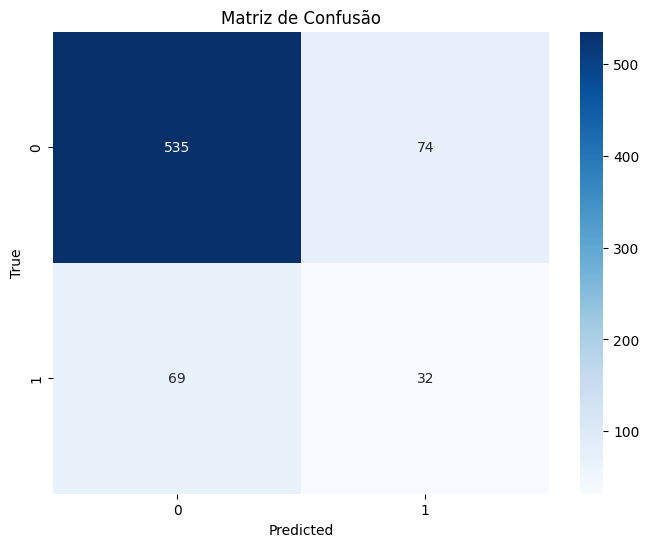

CarbonTracker: WARNING - ElectricityMaps API key not set. Will default to average carbon intensity.
CarbonTracker: WARNING - Failed to retrieve carbon intensity: Defaulting to average carbon intensity 98.34824 gCO2/kWh.
CarbonTracker: WARNING - ElectricityMaps API key not set. Will default to average carbon intensity.
CarbonTracker: WARNING - Failed to retrieve carbon intensity: Defaulting to average carbon intensity 98.34824 gCO2/kWh.
CarbonTracker: WARNING - ElectricityMaps API key not set. Will default to average carbon intensity.
CarbonTracker: WARNING - Failed to retrieve carbon intensity: Defaulting to average carbon intensity 98.34824 gCO2/kWh.
CarbonTracker: WARNING - ElectricityMaps API key not set. Will default to average carbon intensity.
CarbonTracker: WARNING - Failed to retrieve carbon intensity: Defaulting to average carbon intensity 98.34824 gCO2/kWh.
CarbonTracker: WARNING - ElectricityMaps API key not set. Will default to average carbon intensity.
CarbonTracker: WARNI

In [ ]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Matriz de Confusão')
plt.show()